In [1]:
import os
import sys

import logging

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import argparse
import dataclasses
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm

import jax
import optax

from graphcast import checkpoint, data_utils, rollout, graphcast, normalization
import save_params_utils
import setup_jax_functions
from plotting import scale, select, plot_data, save_animation, save_static_plot
from metrics import compute_rmse, compute_mae, compute_bias, compute_acc
import matplotlib.pyplot as plt
# import pynvml
import time

current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")

# jax.config.update('jax_disable_jit', True)

# for memory efficiency
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']='false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '2.0' 
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

mean_by_level = None
stddev_by_level = None
diffs_stddev_by_level = None
model_config = None
task_config = None
params = None
state = None

def generate_sample_era5_dataset(
    date='2022-01-01', 
    model_config = None,
    task_config = None,
    time_steps=4
):
    """
    Generate a sample ERA5 dataset with random values matching original specifications.
    
    Parameters:
    - date: Base date for the dataset
    - lon_res: Longitude resolution
    - lat_res: Latitude resolution
    - levels: Number of vertical levels
    - time_steps: Number of time steps
    
    Returns:
    xr.Dataset with random values
    """
    lons = np.arange(0, 360, model_config.resolution)
    lats = np.arange(-90, 90 + model_config.resolution, model_config.resolution)
    # if task_config.levels == 13:
    level_values = np.array(task_config.pressure_levels)
    # level_values = np.array([1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 125, 150, 175, 200, 
    #                           225, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 
    #                           750, 775, 800, 825, 850, 875, 900, 925, 950, 975, 1000])
    times = pd.timedelta_range(start='0 days', periods=time_steps, freq='6h')
    
    base_datetime = pd.to_datetime(date)

    base_datetime = pd.to_datetime(date)
    datetime_coords = np.array([base_datetime + pd.Timedelta(t) for t in times])
    
    ds = xr.Dataset(
        data_vars={
            'geopotential_at_surface': (['lat', 'lon'], np.random.uniform(20000, 30000, size=(len(lats), len(lons)))),
            'land_sea_mask': (['lat', 'lon'], np.random.choice([0.0, 1.0], size=(len(lats), len(lons)))),
            '2m_temperature': (['batch', 'time', 'lat', 'lon'], np.random.uniform(240, 310, size=(1, len(times), len(lats), len(lons)))),
            'mean_sea_level_pressure': (['batch', 'time', 'lat', 'lon'], np.random.uniform(95000, 105000, size=(1, len(times), len(lats), len(lons)))),
            '10m_v_component_of_wind': (['batch', 'time', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(lats), len(lons)))),
            '10m_u_component_of_wind': (['batch', 'time', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(lats), len(lons)))),
            'total_precipitation_6hr': (['batch', 'time', 'lat', 'lon'], np.random.uniform(0, 0.01, size=(1, len(times), len(lats), len(lons)))),
            'toa_incident_solar_radiation': (['batch', 'time', 'lat', 'lon'], np.random.uniform(0, 2000000, size=(1, len(times), len(lats), len(lons)))),
            'temperature': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(250, 300, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'geopotential': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(0, 500000, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'u_component_of_wind': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'v_component_of_wind': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'vertical_velocity': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(-1, 1, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'specific_humidity': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(0, 0.01, size=(1, len(times), len(level_values), len(lats), len(lons))))
        },
        coords={
            'lon': lons,
            'lat': lats,
            'level': level_values,
            'time': times,
            'datetime': (['batch', 'time'], datetime_coords.reshape(1, -1)),
            'batch': [0]
        }
    )
    
    return ds


# modify the gradients function signature (needed for finetuning with optax)
def grads_fn(params, state, inputs, targets, forcings, model_config, task_config):
    def _aux(params, state, i, t, f):
        (loss, diagnostics), next_state = setup_jax_functions.loss_fn.apply(params, state, jax.random.PRNGKey(0), model_config, task_config, i, t, f)
        return loss, (diagnostics, next_state)
    (loss, (diagnostics, next_state)), grads = jax.value_and_grad(_aux, has_aux=True)(params, state, inputs, targets, forcings)
    return loss, diagnostics, next_state, grads


In [2]:
station_df = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/modified_era5_stations_2021_sept.nc")
station_df

<xarray.Dataset> Size: 7GB
Dimensions:                  (time: 117, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
  * time                     (time) datetime64[ns] 936B 2021-07-01 ... 2021-0...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 30MB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 30MB ...
    2m_temperature           (time, latitude, longitude) float32 30MB ...
    geopotential             (time, level, latitude, longitude) float32 1GB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB ...
    land_sea_mask            (latitude, longitude) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 1GB ...
    temperature              (time, level, latitude, longitude) float32 1GB ...
    total_precipitation_6hr  (time, latitude, longitude) float32 30MB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 1GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 1GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 1GB ...

In [22]:
station_df_init = station_df.isel(time=slice(-40, -1))
station_df_init

<xarray.Dataset> Size: 2GB
Dimensions:                  (time: 39, latitude: 181, longitude: 360, level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
  * time                     (time) datetime64[ns] 312B 2021-07-20T06:00:00 ....
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 10MB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 10MB ...
    2m_temperature           (time, latitude, longitude) float32 10MB ...
    geopotential             (time, level, latitude, longitude) float32 376MB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB ...
    land_sea_mask            (latitude, longitude) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 376MB ...
    temperature              (time, level, latitude, longitude) float32 376MB ...
    total_precipitation_6hr  (time, latitude, longitude) float32 10MB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 376MB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 376MB ...
    vertical_velocity        (time, level, latitude, longitude) float32 376MB ...

In [23]:
inits = 4
global mean_by_level
global stddev_by_level
global diffs_stddev_by_level
global model_config
global task_config
global params
global state

log_file = f"loggers/printing_logs{current_date}.log"
logging.basicConfig(filename=log_file, level=logging.INFO, format="%(asctime)s - %(message)s")
logger = logging.getLogger()
logger.info("Starting the script")

model_levels = 13
model_resolution = 1.0
if model_levels == 37:
    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_0.25_37.npz'
        
elif model_resolution == 0.25:
    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_0.25_13.npz'
    
    with open(f'/Datastorage/saptarishi.dhanuka_asp25/era5_data/graphcast_dataset_source-era5_date-2022-01-01_res-{args.model_resolution}_levels-13_steps-12.nc', 'rb') as f:
        logger.info("Loading Dataset")
        tik = datetime.now()
        training_trial_batch = xr.load_dataset(f).compute()
        tok = datetime.now()
        logger.info(f"Dataset loaded in {tok - tik}")

else:

    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/origs/graphcast_1_13.npz'
    dataset_name = "/Datastorage/saptarishi.dhanuka_asp25/era5_data/arco_era5_1.0_formatted.nc"

    arco = station_df_init
    
    old_lats = arco['latitude'].values
    old_lons = arco['longitude'].values
    new_lats = np.arange(-90.0, 90.0 + 1e-8, 1.0)
    new_lats = np.flip(new_lats)
    new_lons = np.arange(0, 359.75 + 1e-8, 1.0)
    arco = arco.interp({'latitude': new_lats, 'longitude': new_lons}, 
                            method='linear',
                            kwargs={'fill_value': None})
    
    input_vars = ['10m_u_component_of_wind',
                'geopotential_at_surface',
                '10m_v_component_of_wind',
                'specific_humidity',
                'land_sea_mask',
                'vertical_velocity',
                'geopotential',
                'v_component_of_wind',
                'temperature',
                'total_precipitation_6hr',
                'mean_sea_level_pressure',
                '2m_temperature',
                'u_component_of_wind']
    
    # arco = arco.drop_vars(['toa_incident_solar_radiation',
    # 'year_progress_sin',
    # 'year_progress_cos',
    # 'day_progress_sin',
    # 'day_progress_cos','cos_latitude',
    # 'cos_longitude','sin_longitude'])

    # arco = arco.rename({'total_precipitation': 'total_precipitation_6hr'})

    arco = arco.expand_dims(batch=1)
    arco = arco.rename({'latitude': 'lat', 'longitude': 'lon'})

    datetime_array = arco['time'].values
    # Calculate the time coordinate in 6-hour increments (in nanoseconarco)
    time_array = np.arange(0, len(datetime_array) * 21600000000000, 21600000000000, dtype='timedelta64[ns]')

    # Add the new 'time' coordinate to the dataset
    arco1 = arco.assign_coords(datetime=('time', time_array))

    temp_time = arco1.coords["time"].copy()
    temp_datetime = arco1.coords["datetime"].copy()

    # Reassign the coordinates, swapping their values
    arco1 = arco1.assign_coords(
        time=temp_datetime,
        datetime=temp_time
    )

    logger.info("Coordinates first time")
    logger.info(arco1)
    logger.info("\n")
    logger.info(arco1.coords)
    logger.info("\n")


    # arco1['geopotential_at_surface'] = arco1['geopotential_at_surface'].isel(batch=0, time=0)
    # arco1['land_sea_mask'] = arco1['land_sea_mask'].isel(batch=0, time=0)

    old_datetime = arco1["datetime"].values  # shape (1489,)

    # For our purposes, we want the coordinate to have shape (batch, time). Since the batch
    # dimension is of length 1, we can simply add a new axis.
    new_datetime = old_datetime[np.newaxis, :]  # shape becomes (1, 1489)

    # Now, reassign the "datetime" coordinate to have dims ("batch", "time").
    arco1 = arco1.assign_coords(datetime=(("batch", "time"), new_datetime))

    print(f"Coordinates after reassigning: {arco1.coords}\n")


    logger.info(arco1.nbytes)

    # select_time = arco1.isel(time=slice(0, 240))
    tik = datetime.now()

    select_time_eval = arco1

    eval_trial_batch = select_time_eval.load()



    # select_time_evals = [imerg_test.isel(time=slice(i*26, i*28+30)) for i in range(inits)]


    print(f"Eval batch first time: {eval_trial_batch.time.values}")
    # training_trial_batch = select_time.load()

    tok = datetime.now()
    # training_trial_batch = training_trial_batch.rename({'time': 'datetime'})
    logger.info("Training batch time")
    # logger.info(training_trial_batch.coords)
    logger.info(f"Dataset loaded in {tok - tik}")

    # with open("/Datastorage/saptarishi.dhanuka_asp25/era5_data/dataset_source-era5_date-2022-01-01_res-1.0_levels-13_steps-40.nc", 'rb') as f:
    #     print("Loading Dataset")
    #     tik = datetime.now()
    #     training_trial_batch = xr.load_dataset(f).compute()
    #     # training_trial_batch = training_trial_batch.isel(time=slice(0, 12))
    #     # training_trial_batch = training_trial_batch.rename({'time': 'datetime'})
    #     print("Training batch time")
    #     print(training_trial_batch.datetime)
    #     tok = datetime.now()
    #     print(f"Dataset loaded in {tok - tik}")


with open(filename, 'rb') as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)

params = ckpt.params


with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/diffs_stddev_by_level.nc', 'rb') as f:
    diffs_stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/stddev_by_level.nc', 'rb') as f:
    stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/mean_by_level.nc', 'rb') as f:
    mean_by_level = xr.load_dataset(f).compute()


state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config
logger.info(model_config)
logger.info(task_config)
setup_jax_functions.configs['model_config'] = model_config
setup_jax_functions.configs['task_config'] = task_config
setup_jax_functions.configs['state'] = state
setup_jax_functions.configs['params'] = params
setup_jax_functions.configs['stddev_by_level'] = stddev_by_level
setup_jax_functions.configs['diffs_stddev_by_level'] = diffs_stddev_by_level
setup_jax_functions.configs['mean_by_level'] = mean_by_level

setup_jax_functions.update_configs({
    'params': ckpt.params,
    'state': {},
    'model_config': ckpt.model_config,
    'task_config': ckpt.task_config,
    'mean_by_level': mean_by_level,
    'stddev_by_level': stddev_by_level,
    'diffs_stddev_by_level': diffs_stddev_by_level
})

init_jitted = jax.jit(setup_jax_functions.with_configs(setup_jax_functions.run_forward.init))
loss_fn_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.loss_fn.apply))))
grads_fn_jitted = setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.grads_fn)))
run_forward_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(
    setup_jax_functions.run_forward.apply))))

def run_model(params, state, inputs, targets_template, forcings):
    predictions = run_forward_jitted(
        rng=jax.random.PRNGKey(0),
        inputs=inputs,
        targets_template=targets_template,
        forcings=forcings,
        params=params,
        state=state
    )
    return predictions


Coordinates after reassigning: Coordinates:
  * level     (level) int64 296B 1 2 3 5 7 10 20 ... 875 900 925 950 975 1000
  * lat       (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    datetime  (batch, time) datetime64[ns] 312B 2021-07-20T06:00:00 ... 2021-...
  * time      (time) timedelta64[ns] 312B 0 days 00:00:00 ... 9 days 12:00:00

Eval batch first time: [              0  21600000000000  43200000000000  64800000000000
  86400000000000 108000000000000 129600000000000 151200000000000
 172800000000000 194400000000000 216000000000000 237600000000000
 259200000000000 280800000000000 302400000000000 324000000000000
 345600000000000 367200000000000 388800000000000 410400000000000
 432000000000000 453600000000000 475200000000000 496800000000000
 518400000000000 540000000000000 561600000000000 583200000000000
 604800000000000 626400000000000 648000000000000 669600000000000
 69120000000000

In [24]:
eval_trial_batch

<xarray.Dataset> Size: 5GB
Dimensions:                  (batch: 1, time: 39, lat: 181, lon: 360, level: 37)
Coordinates:
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    datetime                 (batch, time) datetime64[ns] 312B 2021-07-20T06:...
  * time                     (time) timedelta64[ns] 312B 0 days 00:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float64 20MB -0.1975 ......
    10m_v_component_of_wind  (batch, time, lat, lon) float64 20MB 0.2791 ... ...
    2m_temperature           (batch, time, lat, lon) float64 20MB 273.7 ... 2...
    geopotential             (batch, time, level, lat, lon) float64 752MB 4.9...
    geopotential_at_surface  (batch, lat, lon) float64 521kB -0.07617 ... 2.7...
    land_sea_mask            (batch, lat, lon) float64 521kB 0.0 0.0 ... 1.0 1.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float64 752MB 4.0...
    temperature              (batch, time, level, lat, lon) float64 752MB 286...
    total_precipitation_6hr  (batch, time, lat, lon) float64 20MB 0.0001774 ....
    u_component_of_wind      (batch, time, level, lat, lon) float64 752MB 0.0...
    v_component_of_wind      (batch, time, level, lat, lon) float64 752MB -6....
    vertical_velocity        (batch, time, level, lat, lon) float64 752MB -1....

In [25]:

new_params_path = "/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig_stationbench.npz"

f = open(new_params_path, "rb")
new_ckpt = checkpoint.load(f, graphcast.CheckPoint)
new_params = new_ckpt.params

In [6]:
eval_trial_batch

<xarray.Dataset> Size: 1GB
Dimensions:                  (batch: 1, time: 9, lat: 181, lon: 360, level: 37)
Coordinates:
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    datetime                 (batch, time) datetime64[ns] 72B 2021-07-27T18:0...
  * time                     (time) timedelta64[ns] 72B 0 days 00:00:00 ... 2...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float64 5MB -0.2045 ... ...
    10m_v_component_of_wind  (batch, time, lat, lon) float64 5MB -0.1605 ... ...
    2m_temperature           (batch, time, lat, lon) float64 5MB 273.5 ... 234.5
    geopotential             (batch, time, level, lat, lon) float64 174MB 4.8...
    geopotential_at_surface  (batch, lat, lon) float64 521kB -0.07617 ... 2.7...
    land_sea_mask            (batch, lat, lon) float64 521kB 0.0 0.0 ... 1.0 1.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float64 174MB 3.9...
    temperature              (batch, time, level, lat, lon) float64 174MB 284...
    total_precipitation_6hr  (batch, time, lat, lon) float64 5MB 0.000142 ......
    u_component_of_wind      (batch, time, level, lat, lon) float64 174MB -0....
    v_component_of_wind      (batch, time, level, lat, lon) float64 174MB -0....
    vertical_velocity        (batch, time, level, lat, lon) float64 174MB -0....

In [34]:
import cartopy.crs as ccrs
import xarray as xr

latmax = 38
latmin = 6
lonmin = 68
lonmax = 98



def plot_difference_with_stations(preds_finetuned, targets, time_step, var_name):
    pass









def plot_difference_with_targets_fine_sims(preds_finetuned, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    temperature_pred_finetuned = preds_finetuned[var_name]
    temperature_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets
    temp_finetuned = temperature_pred_finetuned.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_finetuned - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_finetuned{time_step}_imerg1.png')
    plt.close()

    return (difference)



def plot_difference_with_targets_base_sims(preds_old, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    temperature_pred_old = preds_old[var_name]
    temperature_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets
    temp_base = temperature_pred_old.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_base - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_base{time_step}_imerg1.png')
    plt.close()

    return (difference)


def plot_diff_imd_era5_sims(pred_imd, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    # if var_name == 'total_precipitation_6hr':
    #     pred_imd = preds_old['tp']
        
    temperature_targets = targets[var_name]

    # imd lat order is reversed

    pred_imd = pred_imd.rename({'latitude': 'lat', 'longitude': 'lon'})
    temp_imd = pred_imd.sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step,batch=0).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_imd - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"IMD Prediction vs Ground Truth at Time Step {time_step} for {var_name}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_imd_era5_{var_name}.png')
    plt.close()

    return (difference)


In [14]:
imd_july_2022 = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/imd_forecasts/imd_july2022_7_days.grib")
old_lats = imd_july_2022['latitude'].values
old_lons = imd_july_2022['longitude'].values
new_lats = np.arange(-90.0, 90.0 + 1e-8, 1.0)
new_lats = np.flip(new_lats)
new_lons = np.arange(0, 359.75 + 1e-8, 1.0)
imd_july_2022 = imd_july_2022.interp({'latitude': new_lats, 'longitude': new_lons}, 
                        method='linear',
                        kwargs={'fill_value': None})
imd_july_2022

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 847MB
Dimensions:            (time: 28, step: 29, latitude: 181, longitude: 360)
Coordinates:
    number             int64 8B 0
  * time               (time) datetime64[ns] 224B 2022-07-01 ... 2022-07-28
  * step               (step) timedelta64[ns] 232B 0 days 00:00:00 ... 7 days...
    heightAboveGround  float64 8B 2.0
    valid_time         (time, step) datetime64[ns] 6kB 2022-07-01 ... 2022-08-04
    surface            float64 8B 0.0
  * latitude           (latitude) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * longitude          (longitude) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
Data variables:
    t2m                (time, step, latitude, longitude) float64 423MB 273.3 ...
    tp                 (time, step, latitude, longitude) float64 423MB 0.0 .....
Attributes:
    GRIB_edition:            2
    GRIB_centre:             vabb
    GRIB_centreDescription:  New Delhi
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             New Delhi
    history:                 2025-04-30T23:00 GRIB to CDM+CF via cfgrib-0.9.1...

In [9]:
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
eval_trial_batch.load(), target_lead_times=slice("6h", "48h"),
**dataclasses.asdict(task_config))
eval_targets

<xarray.Dataset> Size: 346MB
Dimensions:                  (batch: 1, time: 8, lat: 181, lon: 360, level: 13)
Coordinates:
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * time                     (time) timedelta64[ns] 64B 0 days 06:00:00 ... 2...
Dimensions without coordinates: batch
Data variables:
    2m_temperature           (batch, time, lat, lon) float64 4MB 273.9 ... 234.5
    mean_sea_level_pressure  (batch, time, lat, lon) float64 4MB 1.016e+05 .....
    10m_v_component_of_wind  (batch, time, lat, lon) float64 4MB 0.08327 ... ...
    10m_u_component_of_wind  (batch, time, lat, lon) float64 4MB -0.3418 ... ...
    total_precipitation_6hr  (batch, time, lat, lon) float64 4MB 0.0001781 .....
    temperature              (batch, time, level, lat, lon) float64 54MB 229....
    geopotential             (batch, time, level, lat, lon) float64 54MB 2.07...
    u_component_of_wind      (batch, time, level, lat, lon) float64 54MB -0.0...
    v_component_of_wind      (batch, time, level, lat, lon) float64 54MB 0.00...
    vertical_velocity        (batch, time, level, lat, lon) float64 54MB 0.00...
    specific_humidity        (batch, time, level, lat, lon) float64 54MB 2.99...

In [16]:
eval_targets.isel(time=-1).isel(batch=0).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()

<xarray.Dataset> Size: 680kB
Dimensions:                  (lat: 33, lon: 31, level: 13)
Coordinates:
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 264B 38.0 37.0 36.0 ... 8.0 7.0 6.0
  * lon                      (lon) float64 248B 68.0 69.0 70.0 ... 97.0 98.0
    time                     timedelta64[ns] 8B 2 days
Data variables:
    2m_temperature           (lat, lon) float64 8kB 300.1 300.9 ... 301.6 302.0
    mean_sea_level_pressure  (lat, lon) float64 8kB 9.994e+04 ... 1.011e+05
    10m_v_component_of_wind  (lat, lon) float64 8kB -1.272 0.1905 ... -1.42
    10m_u_component_of_wind  (lat, lon) float64 8kB -1.167 0.5845 ... 3.402
    total_precipitation_6hr  (lat, lon) float64 8kB 0.0 0.0 ... 5.653e-06
    temperature              (level, lat, lon) float64 106kB 211.0 ... 300.0
    geopotential             (level, lat, lon) float64 106kB 2.06e+05 ... 975.8
    u_component_of_wind      (level, lat, lon) float64 106kB -2.537 ... 3.579
    v_component_of_wind      (level, lat, lon) float64 106kB 0.183 ... -1.415
    vertical_velocity        (level, lat, lon) float64 106kB 0.01582 ... 0.05839
    specific_humidity        (level, lat, lon) float64 106kB 2.794e-06 ... 0....

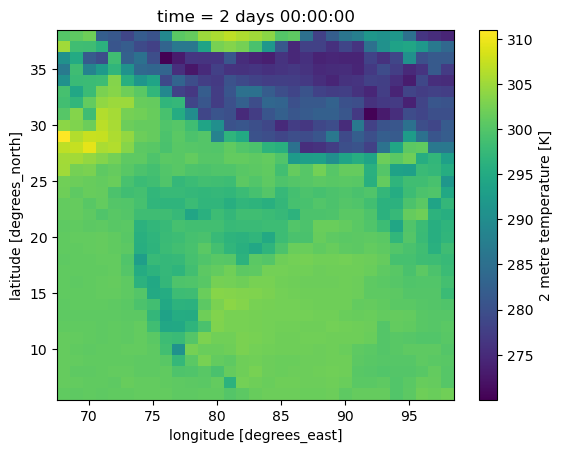

In [19]:
eval_targets.isel(time=-1).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()['2m_temperature'].plot()

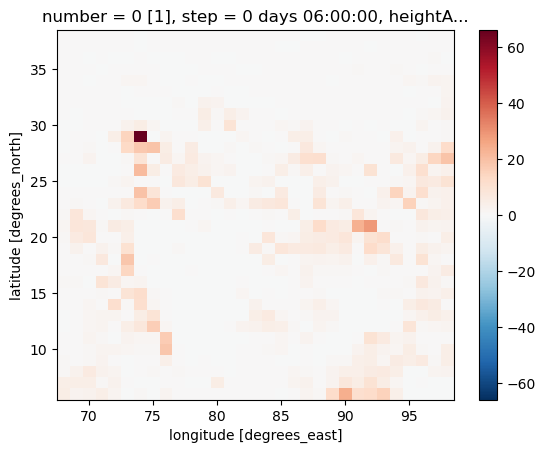

In [21]:
diff = inited_imd['tp'].isel(step=1).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze() - eval_targets.isel(time=0)['total_precipitation_6hr'].isel(batch=0).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
diff.plot()

In [27]:
eval_trial_batch

<xarray.Dataset> Size: 5GB
Dimensions:                  (batch: 1, time: 39, lat: 181, lon: 360, level: 37)
Coordinates:
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    datetime                 (batch, time) datetime64[ns] 312B 2021-07-20T06:...
  * time                     (time) timedelta64[ns] 312B 0 days 00:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float64 20MB -0.1975 ......
    10m_v_component_of_wind  (batch, time, lat, lon) float64 20MB 0.2791 ... ...
    2m_temperature           (batch, time, lat, lon) float64 20MB 273.7 ... 2...
    geopotential             (batch, time, level, lat, lon) float64 752MB 4.9...
    geopotential_at_surface  (batch, lat, lon) float64 521kB -0.07617 ... 2.7...
    land_sea_mask            (batch, lat, lon) float64 521kB 0.0 0.0 ... 1.0 1.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float64 752MB 4.0...
    temperature              (batch, time, level, lat, lon) float64 752MB 286...
    total_precipitation_6hr  (batch, time, lat, lon) float64 20MB 0.0001774 ....
    u_component_of_wind      (batch, time, level, lat, lon) float64 752MB 0.0...
    v_component_of_wind      (batch, time, level, lat, lon) float64 752MB -6....
    vertical_velocity        (batch, time, level, lat, lon) float64 752MB -1....

In [28]:
import warnings
warnings.filterwarnings('ignore')

In [29]:
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
eval_trial_batch.load(), target_lead_times=slice("6h", "48h"),
**dataclasses.asdict(task_config))

assert eval_trial_batch.sizes["time"] >= 3

logger.info(f"Eval batch time dimensions: {eval_trial_batch.sizes['time']}")

task_config_dict =  dataclasses.asdict(task_config)
# task_config_dict.pop('input_duration')

print("Eval Inputs:   ", eval_inputs.dims.mapping)
print("Eval Targets:  ", eval_targets.dims.mapping)
print("Eval Forcings: ", eval_forcings.dims.mapping)

targets_template = eval_targets * np.nan

print("Running old params")
predictions_old = run_model(params, state, eval_inputs, targets_template, eval_forcings)

print("Predictions Old: ", predictions_old.dims.mapping)


print("Running new params")

predictions_finetuned = run_model(new_params, state, eval_inputs, targets_template, eval_forcings)
print("Predictions Finetuned: ", predictions_finetuned.dims.mapping)


predictions_old.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2021_stations.nc")
predictions_finetuned.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetune_india2021_stations.nc")

Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 8, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 8, 'lat': 181, 'lon': 360}
Running old params
Predictions Old:  {'time': 8, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Running new params
Predictions Finetuned:  {'time': 8, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


In [33]:
eval_targets

<xarray.Dataset> Size: 346MB
Dimensions:                  (batch: 1, time: 8, lat: 181, lon: 360, level: 13)
Coordinates:
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * time                     (time) timedelta64[ns] 64B 0 days 06:00:00 ... 2...
Dimensions without coordinates: batch
Data variables:
    2m_temperature           (batch, time, lat, lon) float64 4MB 273.9 ... 234.5
    mean_sea_level_pressure  (batch, time, lat, lon) float64 4MB 1.016e+05 .....
    10m_v_component_of_wind  (batch, time, lat, lon) float64 4MB 0.08327 ... ...
    10m_u_component_of_wind  (batch, time, lat, lon) float64 4MB -0.3418 ... ...
    total_precipitation_6hr  (batch, time, lat, lon) float64 4MB 0.0001781 .....
    temperature              (batch, time, level, lat, lon) float64 54MB 229....
    geopotential             (batch, time, level, lat, lon) float64 54MB 2.07...
    u_component_of_wind      (batch, time, level, lat, lon) float64 54MB -0.0...
    v_component_of_wind      (batch, time, level, lat, lon) float64 54MB 0.00...
    vertical_velocity        (batch, time, level, lat, lon) float64 54MB 0.00...
    specific_humidity        (batch, time, level, lat, lon) float64 54MB 2.99...

100%|██████████| 6/6 [00:01<00:00,  5.54it/s]


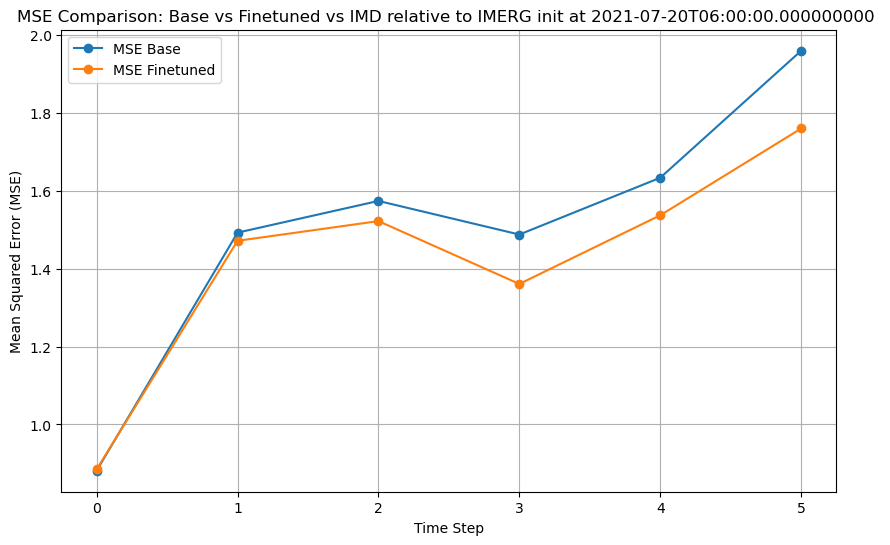

<Figure size 640x480 with 0 Axes>

In [36]:
import cartopy.crs as ccrs
from datetime import datetime
current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")

#iterates over the initialization of the model

# predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_2015_{i}_imerg.nc")
# predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_full_2015_{i}_imerg.nc")
# eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
# eval_trial_batch.load(), target_lead_times=slice("6h", "168h"),
# **dataclasses.asdict(task_config))


variable_name = '2m_temperature'

# Plot differences with ground truth for each time step
differences_finetuned = []
differences_base = []
differences_era5_imd = []
for time_step in tqdm(range(6)):
    differences_finetuned.append(plot_difference_with_targets_fine_sims(predictions_finetuned,eval_targets,time_step, variable_name))
    differences_base.append(plot_difference_with_targets_base_sims(predictions_old,eval_targets,time_step, variable_name))
    # imd_6h_converted = (imd_july_2022_temp.isel(step=time_step+1)['tp'] - imd_july_2022_temp.isel(step=time_step)['tp'])/1000
    # differences_era5_imd.append(plot_diff_imd_era5_sims(imd_6h_converted,eval_targets,time_step, variable_name))

# print(differences_finetuned)
# print(differences_base)

# print("Finetuned differences: ", differences_finetuned)
# print("Base differences: ", differences_base)



def compute_mse(predictions, targets):
    return ((predictions - targets) ** 2).mean()

def compute_mse_diffs(diff):
    return (diff ** 2).mean(dim=["lat", "lon"]).values

# Compute the MSE for each time step and aggregate
mse_finetuned = []
mse_base = []
# mse_imd_era5 = []
for diff_counter in range(len(differences_finetuned)):
    mse_diff_finetuned = compute_mse_diffs(differences_finetuned[diff_counter])
    mse_diff_base = compute_mse_diffs(differences_base[diff_counter])
    # mse_diff_imd_era5 = compute_mse_diffs(differences_era5_imd[diff_counter])
    
    mse_finetuned.append(mse_diff_finetuned)
    mse_base.append(mse_diff_base)
    # mse_imd_era5.append(mse_diff_imd_era5)

# print(mse_base)
# print()
# print(mse_finetuned)




# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(list(range(6)), mse_base, label='MSE Base', marker='o')
plt.plot(list(range(6)), mse_finetuned, label='MSE Finetuned', marker='o')
# plt.plot(list(range(6)), mse_imd_era5, label='MSE IMD', marker='o')
# plt.plot(time_steps, mse_imd_era5, label='MSE IMD ERA5', marker='x')

    # Annotate the first and last points for MSE Base
# plt.annotate(f"{mse_base[0]:.4f}", (0, mse_base[0]), textcoords="offset points", xytext=(-10, 10), ha='center')
# plt.annotate(f"{mse_base[-1]:.4f}", (6, mse_base[-1]), textcoords="offset points", xytext=(-10, 10), ha='center')


# Add labels, title, and legend
plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE Comparison: Base vs Finetuned vs IMD relative to IMERG init at {eval_trial_batch.datetime.values[0][0]} ')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
# plt.savefig(f"./final_plots/metrics/mse_comparison_finetuned_base_{i}_{current_date}.png")
plt.clf()


In [102]:
mse_imd_era5

[array(288.31151664),
 array(288.31151664),
 array(288.31151664),
 array(288.31151664),
 array(288.31151664),
 array(288.31151664),
 array(288.31151664)]

The graphcast will still need to be initialised over the whole world with the era5 data but we can then separately eval with multiple simulations on the imerg data

In [14]:
select_time_eval

<xarray.Dataset> Size: 3GB
Dimensions:                  (batch: 1, time: 64, lat: 181, lon: 360, level: 13)
Coordinates:
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    datetime                 (batch, time) datetime64[ns] 512B 2015-06-02T18:...
  * time                     (time) timedelta64[ns] 512B 1 days 18:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float64 33MB -0.4316 ......
    10m_v_component_of_wind  (batch, time, lat, lon) float64 33MB -0.4835 ......
    2m_temperature           (batch, time, lat, lon) float64 33MB 272.8 ... 2...
    geopotential             (batch, time, level, lat, lon) float64 434MB 2.0...
    geopotential_at_surface  (batch, lat, lon) float64 521kB -0.07617 ... 2.7...
    land_sea_mask            (batch, lat, lon) float64 521kB 0.0 0.0 ... 1.0 1.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float64 434MB 2.7...
    temperature              (batch, time, level, lat, lon) float64 434MB 229...
    total_precipitation_6hr  (batch, time, lat, lon) float64 33MB 0.0001008 ....
    u_component_of_wind      (batch, time, level, lat, lon) float64 434MB -0....
    v_component_of_wind      (batch, time, level, lat, lon) float64 434MB 0.0...
    vertical_velocity        (batch, time, level, lat, lon) float64 434MB -0....

In [19]:

new_params_path = "/Datastorage/saptarishi.dhanuka_asp25/gc_weights/finetuned/graphcast_1_13_imerg26_4_2015.npz"

f = open(new_params_path, "rb")
new_ckpt = checkpoint.load(f, graphcast.CheckPoint)
new_params = new_ckpt.params

In [ ]:
jax.config.update("jax_enable_x64", True)


In [22]:
eval_trial_batch

<xarray.Dataset> Size: 5GB
Dimensions:                  (batch: 1, time: 120, lat: 181, lon: 360, level: 13)
Coordinates:
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    datetime                 (batch, time) datetime64[ns] 960B 2015-09-01 ......
  * time                     (time) timedelta64[ns] 960B 0 days 00:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float64 63MB -0.2194 ......
    10m_v_component_of_wind  (batch, time, lat, lon) float64 63MB -0.09066 .....
    2m_temperature           (batch, time, lat, lon) float64 63MB 270.7 ... 2...
    geopotential             (batch, time, level, lat, lon) float64 813MB 2.0...
    geopotential_at_surface  (batch, lat, lon) float64 521kB -0.07617 ... 2.7...
    land_sea_mask            (batch, lat, lon) float64 521kB 0.0 0.0 ... 1.0 1.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float64 813MB 2.8...
    temperature              (batch, time, level, lat, lon) float64 813MB 225...
    total_precipitation_6hr  (batch, time, lat, lon) float64 63MB 0.0001923 ....
    u_component_of_wind      (batch, time, level, lat, lon) float64 813MB 0.0...
    v_component_of_wind      (batch, time, level, lat, lon) float64 813MB -0....
    vertical_velocity        (batch, time, level, lat, lon) float64 813MB 0.0...

In [24]:
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
eval_trial_batch, target_lead_times=slice("6h", "168h"),
**dataclasses.asdict(task_config))

targets_template = eval_targets * np.nan


In [25]:
predictions_old = run_model(params, state, eval_inputs, targets_template, eval_forcings)

print("Predictions Old: ", predictions_old.dims.mapping)

Predictions Old:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


In [26]:
print("Running new params")

predictions_finetuned = run_model(new_params, state, eval_inputs, targets_template, eval_forcings)
print("Predictions Finetuned: ", predictions_finetuned.dims.mapping)


Running new params
Predictions Finetuned:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


In [27]:
predictions_old.to_netcdf("/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_imerg_sept2015.nc")
predictions_finetuned.to_netcdf("/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_imerg_sept2015.nc")

In [30]:
import cartopy.crs as ccrs

# Extract the variable of interest (e.g., '2m_variable')
variable_name = 'total_precipitation_6hr'
variable_pred_old = predictions_old[variable_name]
variable_pred_finetuned = predictions_finetuned[variable_name]
variable_targets = eval_targets[variable_name]

In [39]:
variable_pred_finetuned

<xarray.DataArray 'total_precipitation_6hr' (time: 28, batch: 1, lat: 181,
                                             lon: 360)> Size: 15MB
xarray_jax.JaxArrayWrapper(Array([[[[ 1.17241309e-04,  1.17241309e-04,  1.16777323e-04, ...,
           1.21881169e-04,  1.12369456e-04,  1.19097253e-04],
         [ 1.50223086e-04,  1.50687072e-04,  1.59966792e-04, ...,
           1.63345630e-04,  1.57578870e-04,  1.60726376e-04],
         [ 1.15560122e-04,  1.17186596e-04,  1.17057522e-04, ...,
           1.16512926e-04,  1.09393522e-04,  1.16717563e-04],
         ...,
         [ 1.99625730e-05,  1.18428183e-05,  1.74106501e-05, ...,
           1.03348639e-05,  1.67146711e-05,  1.38727570e-05],
         [ 2.14705274e-05,  2.72703521e-05,  2.04265589e-05, ...,
           1.52067167e-05,  1.91505975e-05,  2.37904573e-05],
         [ 5.87976861e-05,  6.52934898e-05,  5.62457632e-05, ...,
           5.36938403e-05,  5.85656931e-05,  5.87976861e-05]]],


       [[[ 1.70831689e-04,  1.69207738e-04,  1.68743752e-04, ...,
           1.75703542e-04,  1.73615605e-04,  1.71527668e-04],
         [ 1.76438294e-04,  1.77250270e-04,  1.84790042e-04, ...,
           1.89096852e-04,  1.81706141e-04,  1.75805921e-04],
         [ 1.41079351e-04,  1.40617888e-04,  1.41416786e-04, ...,
...
           4.75161850e-07,  2.56309875e-06, -3.36813613e-07],
         [-4.86493536e-05, -5.09112853e-05, -5.83350610e-05, ...,
          -5.50871591e-05, -4.66194150e-05, -5.48551661e-05],
         [ 6.05376335e-05,  4.55740857e-05,  4.35441470e-05, ...,
           4.81260085e-05,  4.94599682e-05,  4.34281505e-05]]],


       [[[ 1.05177673e-04,  1.02683749e-04,  1.00769806e-04, ...,
           1.00073828e-04,  9.20120711e-05,  1.03205733e-04],
         [ 2.11237242e-04,  2.15181123e-04,  2.07757348e-04, ...,
           2.28187671e-04,  2.26828777e-04,  2.12808802e-04],
         [ 1.13588181e-04,  1.06630915e-04,  9.96580483e-05, ...,
           1.18368870e-04,  1.26097017e-04,  1.19385482e-04],
         ...,
         [ 2.15285256e-05,  2.52404135e-05,  1.31187798e-05, ...,
           1.32927745e-05,  1.54387097e-05,  1.48587272e-05],
         [-7.60245264e-05, -7.38785912e-05, -8.26943248e-05, ...,
          -7.99104090e-05, -7.53865457e-05, -7.57345352e-05],
         [-2.57637586e-05, -3.79433905e-05, -4.18292731e-05, ...,
          -2.98236359e-05, -3.12735921e-05, -2.98816341e-05]]]],      dtype=float64))
Coordinates:
  * time     (time) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
  * lat      (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Dimensions without coordinates: batch

In [44]:
imerg_test = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/era5_imerg_20150701-2015_india_full_globe.nc").sel(time=slice('2015-09-01T06:00:00.000000000', '2015-09-30'))
imerg_test = imerg_test.rename({'latitude': 'lat', 'longitude': 'lon'})

In [57]:
latmax = 38
latmin = 6
lonmin = 68
lonmax = 98

def plot_difference_with_targets_fine(preds_finetuned, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    temperature_pred_finetuned = preds_finetuned[var_name]
    temperature_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets
    temp_finetuned = temperature_pred_finetuned.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    imerg_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_finetuned - imerg_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_finetuned{time_step}_imerg.png')
    plt.close()

    return (difference)



def plot_difference_with_targets_base(preds_old, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    temperature_pred_old = preds_old[var_name]
    temperature_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets
    temp_base = temperature_pred_old.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    imerg_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_base - imerg_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_base{time_step}_imerg.png')
    plt.close()

    return (difference)

In [ ]:
latmax = 38
latmin = 6
lonmin = 68
lonmax = 98

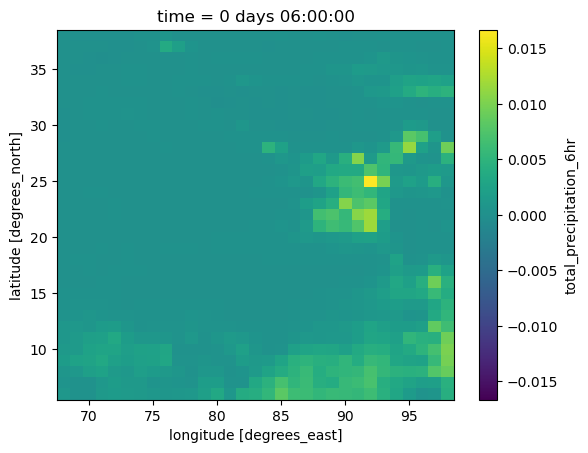

In [58]:
predictions_finetuned.isel(time=0).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax))['total_precipitation_6hr'].plot(cmap='viridis')

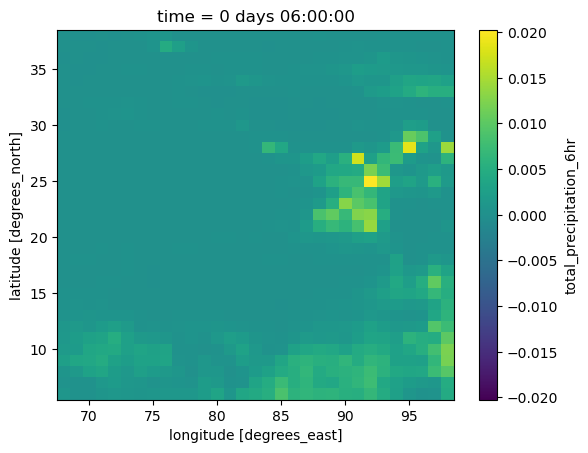

In [70]:
predictions_old.isel(time=0).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax))['total_precipitation_6hr'].plot(cmap='viridis')

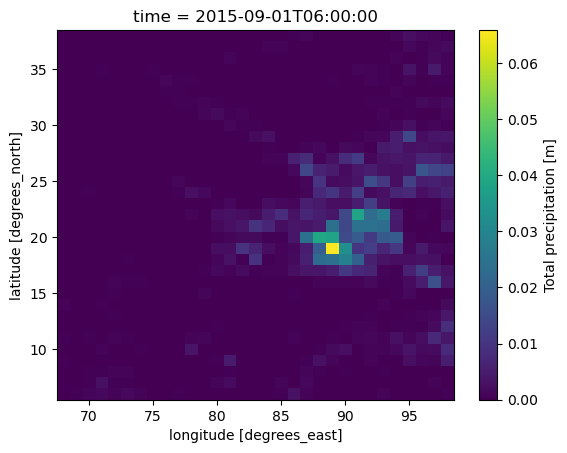

In [68]:
imerg_test.isel(time=0).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))['total_precipitation_6hr'].plot(cmap='viridis')

In [71]:
diff_base = []
diff_fine = []
for i in tqdm(range(7)):
    diff_fine.append(plot_difference_with_targets_fine(predictions_finetuned, imerg_test, i, 'total_precipitation_6hr'))
    diff_base.append(plot_difference_with_targets_base(predictions_old, imerg_test, i, 'total_precipitation_6hr'))


100%|██████████| 7/7 [00:01<00:00,  4.38it/s]


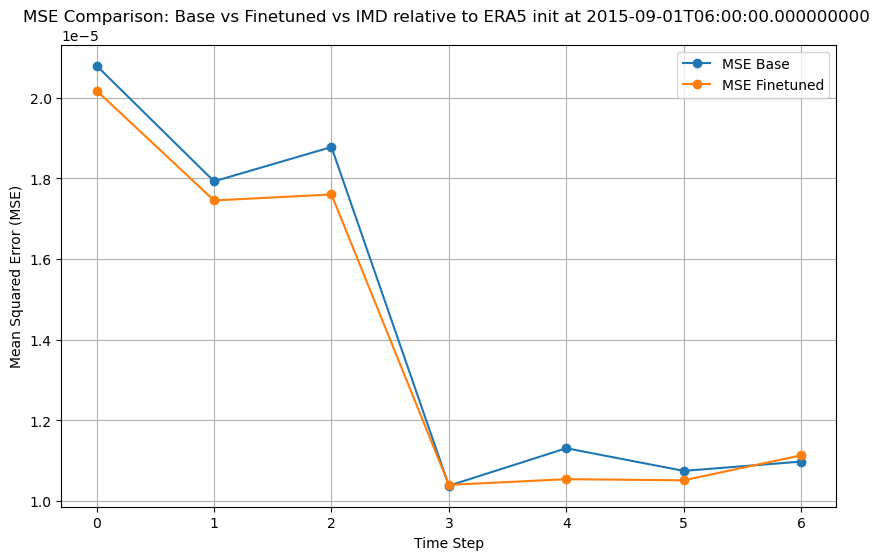

<Figure size 640x480 with 0 Axes>

In [73]:
def compute_mse(predictions, targets):
        return ((predictions - targets) ** 2).mean()

def compute_mse_diffs(diff):
    return (diff ** 2).mean(dim=["lat", "lon"]).values

# Compute the MSE for each time step and aggregate
mse_finetuned = []
mse_base = []
mse_imd_era5 = []
for j in range(len(diff_fine)):
    mse_diff_finetuned = compute_mse_diffs(diff_fine[j])
    mse_diff_base = compute_mse_diffs(diff_base[j])
    # mse_diff_imd_era5 = compute_mse_diffs(differences_era5_imd[i])
    
    mse_finetuned.append(mse_diff_finetuned)
    mse_base.append(mse_diff_base)

# print(mse_base)
# print()
# print(mse_finetuned)




# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(list(range(7)), mse_base, label='MSE Base', marker='o')
plt.plot(list(range(7)), mse_finetuned, label='MSE Finetuned', marker='o')
# plt.plot(time_steps, mse_imd_era5, label='MSE IMD ERA5', marker='x')

    # Annotate the first and last points for MSE Base
# plt.annotate(f"{mse_base[0]:.4f}", (0, mse_base[0]), textcoords="offset points", xytext=(-10, 10), ha='center')
# plt.annotate(f"{mse_base[-1]:.4f}", (6, mse_base[-1]), textcoords="offset points", xytext=(-10, 10), ha='center')


# Add labels, title, and legend
plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE Comparison: Base vs Finetuned vs IMD relative to ERA5 init at {imerg_test.time.values[0]} ')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
# plt.savefig(f"./final_plots/metrics/mse_comparison_finetuned_base_{i}_{current_date}.png")
plt.clf()
